In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression



In [7]:
import zipfile
with zipfile.ZipFile('archive (1).zip', 'r') as zip_ref:
    zip_ref.extractall('dataset')
    print ("Extracted successfully!")


Extracted successfully!


In [8]:
import os
os.listdir('dataset')

['train.csv']

In [9]:
df = pd.read_csv('dataset/train.csv')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [10]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [12]:
# Convert Order Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

# Create monthly sales totals
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()

# Convert to dataframe
monthly_sales = monthly_sales.reset_index()

# Create month number for prediction
monthly_sales['Month_Number'] = range(1, len(monthly_sales) + 1)

monthly_sales.head()

,Order Date,Sales,Month_Number
0,2015-01,14205.707,1
1,2015-02,4519.892,2
2,2015-03,55205.797,3
3,2015-04,27906.855,4
4,2015-05,23644.303,5


In [13]:
X = monthly_sales[['Month_Number']]
y = monthly_sales['Sales']

model = LinearRegression()
model.fit(X, y)
print("model trained successfully!")

model trained successfully!


In [14]:
future_months = pd.DataFrame({'Month_Number': range(len(monthly_sales) + 1, len(monthly_sales) + 7)})
future_sales = model.predict(future_months)

future_predictions = pd.DataFrame({'future month': future_months['Month_Number'], 'predicted_sales': future_sales})
future_predictions

,future month,predicted_sales
0,49,68878.998333
1,50,69767.310525
2,51,70655.622716
3,52,71543.934908
4,53,72432.247100
5,54,73320.559291


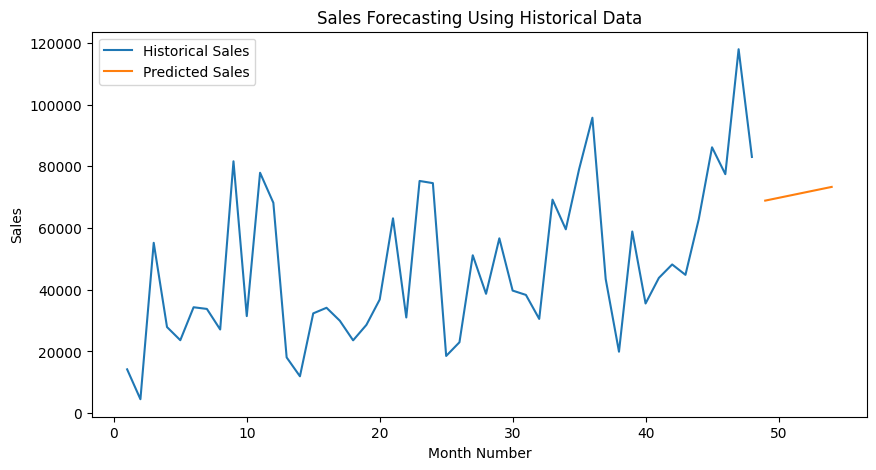

In [15]:
plt.figure(figsize=(10,5))

plt.plot(monthly_sales['Month_Number'],
         monthly_sales['Sales'],
         label='Historical Sales')

plt.plot(future_months['Month_Number'],
         future_sales,
         label='Predicted Sales')

plt.xlabel('Month Number')
plt.ylabel('Sales')
plt.title('Sales Forecasting Using Historical Data')
plt.legend()

plt.show()